# CMR Mine Locations (current and planned mines)

In [69]:
import numpy as np
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

import rasterio
from rasterio.merge import merge
from rasterio.mask import mask

import osmnx as ox

In [70]:
### load CURRENT mines data ###
# data from excel
current_mines_xlsx_path= Path("../data/input/mine-location-data/ahmed-ssa-mine-locations/All Mines SSA_469.xlsx")
current_mines_df = pd.read_excel(current_mines_xlsx_path, sheet_name="All Mines SSA_469")
commodity_code_df = pd.read_excel(current_mines_xlsx_path, sheet_name="Commodities_Code")

# data from shapefile
current_mines_shp_path = Path("../data/input/mine-location-data/ahmed-ssa-mine-locations/All_469_Mines/ALL_469_MINES_IN_SSA.shp")
current_mines_shp_df = gpd.read_file(current_mines_shp_path)

# filter out mines outside Cameroon (COUNTRY_ID = 07)
country_id = 7
current_mines_df = current_mines_df[current_mines_df["COUNTRY_ID"] == country_id]
print(f"number of built mines in Cameroon is {len(current_mines_df)}")

# add a commodity_name column to the current_mines_df and map its 'COMMODITY' column to the commodity_code_df's 'COMMODITY' column to get the data from 'CODE' column
current_mines_df["commodity_name"] = current_mines_df["COMMODITY"].map(
    commodity_code_df.set_index("CODE")["COMMODITY"]
)

### load planned mine data ###
planned_mines_xlsx_path = Path("../data/input/mine-location-data/planned-mine-locations/Mining Dataset Capital IQ 11Nov2023.xlsx")
planned_mines_df = pd.read_excel(planned_mines_xlsx_path, sheet_name="Sheet1")

# filter only mines in Cameroon (COUNTRY_NAME == "Cameroon")
planned_mines_df = planned_mines_df[planned_mines_df["COUNTRY_NAME"] == "Cameroon"]
print(f"number of planned mines in Cameroon is {len(planned_mines_df)}")

# clean the table 
# rename the columns in the planned_mines_df to be more consistent with the current_mines_df's columns
current_mines_df = current_mines_df.rename(columns={
    "LAT_Y": "LATITUDE",
    "LONG_X": "LONGITUDE",
    "commodity_name": "PRIMARY_COMMODITY",
    "MINE_NAME": "PROP_NAME",
    "Mine_ID": "PROP_ID",
    "YEAR_ESTD": "START_UP_YR"
})

# add a new column called 'planned mine' to the current_mines_df and set it to 1 for all rows
current_mines_df["planned_mine"] = 0
# add a new column called 'planned mine' to the planned_mines_df and set it to 0 for all rows
planned_mines_df["planned_mine"] = 1

# merge the current_mines_df and planned_mines_df into one dataframe called all_mines_df
# use the planned_mines_df's columns as the base and add the current_mines_df's columns to it
all_mines_df = pd.concat([planned_mines_df, current_mines_df], ignore_index=True, sort=False)
print(f"number of all mines in Cameroon is {len(all_mines_df)}")

# change the data in the 'all_mines_df' column to be more consistent with the current_mines_df's 'all_mines_df' column
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.lower().str.strip().str.replace(" - ", " ")

# in the 'PRIMARY_COMMODITY' column, replace all instances of "u3o8" with "uranium"
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.replace("u3o8", "uranium")
all_mines_df["PRIMARY_COMMODITY"] = all_mines_df["PRIMARY_COMMODITY"].str.replace("diamonds", "diamond")

all_mines_df = all_mines_df.drop(columns=["COUNTRY_ID", "COMMODITY", "COUNTRY_NAME"])

number of built mines in Cameroon is 13
number of planned mines in Cameroon is 31
number of all mines in Cameroon is 44


In [71]:
### load administrative boundary data ###
# set this to the folder where you unzipped the files
data_dir = Path(r"../data/input/cmr_admin_boundaries_humdata")

# read shapefiles for each admin level
adm1 = gpd.read_file(data_dir / "cmr_admin1.shp")
adm2 = gpd.read_file(data_dir / "cmr_admin2.shp")
adm3 = gpd.read_file(data_dir / "cmr_admin3.shp")

# quick check: print table size
print("adm1 shape:", adm1.shape)
print("adm2 shape:", adm2.shape)
print("adm3 shape:", adm3.shape)

adm1 shape: (10, 22)
adm2 shape: (58, 27)
adm3 shape: (360, 32)


In [85]:
# fill data the STATE_PROVINCE column to all_mines_df based on the latitude and longitude of the mines and the adm1 shapefile
# use adm1_name_col to get the name of the admin-1 region for each mine

all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

adm1_for_join = adm1.to_crs(all_mines_gdf.crs)

# detect admin-1 name column safely (avoids KeyError: '[None] not in index')
candidate_cols = ["adm1_name"]
adm1_name_col = next((c for c in candidate_cols if c in adm1_for_join.columns), None)

if adm1_name_col is None:
    object_cols = [c for c in adm1_for_join.columns if c != "geometry" and adm1_for_join[c].dtype == "object"]
    if not object_cols:
        raise KeyError(f"Could not find an admin-1 name column in adm1. Columns: {list(adm1_for_join.columns)}")
    adm1_name_col = object_cols[0]

adm1_lookup = adm1_for_join[[adm1_name_col, "geometry"]].rename(
    columns={adm1_name_col: "STATE_PROVINCE_FROM_ADM1"}
)

state_join = gpd.sjoin(
    all_mines_gdf[["geometry"]],
    adm1_lookup,
    how="left",
    predicate="intersects"
)

state_by_mine = state_join.groupby(level=0)["STATE_PROVINCE_FROM_ADM1"].first()

if "STATE_PROVINCE" not in all_mines_df.columns:
    all_mines_df["STATE_PROVINCE"] = pd.NA

# always overwrite existing STATE_PROVINCE values with the spatial-join result
all_mines_df["STATE_PROVINCE"] = state_by_mine.reindex(all_mines_df.index)


In [86]:
# save the all_mines_df to a csv file
all_mines_df.to_csv("../data/output/all_mines_df.csv", index=False)

In [87]:
all_mines_df

,PROP_NAME,PROP_ID,PRIMARY_COMMODITY,DEV_STAGE,MINESEARCH_ID,LATITUDE,LONGITUDE,COORDINATE_ACCURACY,STATE_PROVINCE,START_UP_YR,ACTUAL_CLOSURE_YR,EVENT_YR,Mine in Protected Area,planned_mine,MINE_OPERA
0,Akonolinga,51028,iron ore,Exploration,NaN,2.91626,12.16394,Exact,South,NaN,NaN,NaN,NaN,1,NaN
1,Akonolinga,52788,heavy mineral sands,Prefeas/Scoping,NaN,3.78500,12.13800,Exact,Centre,NaN,NaN,NaN,NaN,1,NaN
2,Bangou,65981,bauxite,Grassroots,NaN,5.24000,10.37000,Approximate,West,NaN,NaN,NaN,NaN,1,NaN
3,Batouri,36389,gold,Exploration,118162.0,4.39820,14.40665,Exact,East,NaN,NaN,NaN,NaN,1,NaN
4,Bibemi,50432,gold,Reserves Development,125428.0,9.38893,14.00665,Exact,North,NaN,NaN,NaN,NaN,1,NaN
5,Bikoula,65982,iron ore,Reserves Development,NaN,2.72278,12.39601,Exact,South,NaN,NaN,NaN,Yes,1,NaN
6,Binga,40778,iron ore,Reserves Development,123419.0,2.49806,10.70806,Exact,South,NaN,NaN,NaN,NaN,1,NaN
7,Birsok,65980,bauxite,Target Outline,NaN,6.93000,13.07000,Exact,Adamawa,NaN,NaN,NaN,NaN,1,NaN
8,Cameroon East,32667,cobalt,Feasibility,113860.0,3.33306,13.83333,Exact,East,NaN,NaN,NaN,NaN,1,NaN
9,CLP,90901,gold,Exploration,NaN,7.75841,13.52388,Exact,Adamawa,NaN,NaN,NaN,NaN,1,NaN


In [88]:
### load road network data ###
road_shp_path = Path(r"../data/input/Road_network/liu-cameroon-roads/Cameroon.shp")
cameroon_roads = gpd.read_file(road_shp_path)
cameroon_roads.head()

,ID,Start_pt,End_pt,Rd_length,Surface,geometry
0,1,"(1103991.702615, 328198.947937)","(1103520.286835, 328787.695206)",762.730176,paved,"MULTILINESTRING ((1103991.703 328198.948, 1103..."
1,2,"(1103520.286835, 328787.695206)","(1103479.510506, 327812.637704)",980.028403,paved,"MULTILINESTRING ((1103520.287 328787.695, 1103..."
2,3,"(1094496.606460, 264352.420784)","(1094836.587317, 264478.208504)",364.363710,paved,"MULTILINESTRING ((1094496.606 264352.421, 1094..."
3,4,"(1102316.032584, 283330.554237)","(1101453.228606, 267250.567070)",23257.130654,unpaved,"MULTILINESTRING ((1102316.033 283330.554, 1102..."
4,5,"(1103057.420392, 327326.354672)","(1102985.552529, 327212.146541)",134.938827,paved,"LINESTRING (1103057.42 327326.355, 1102985.553..."


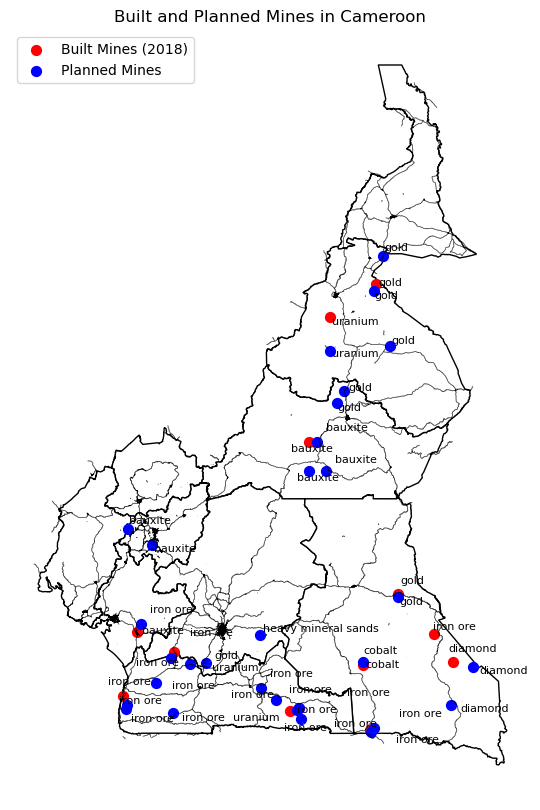

In [94]:
from adjustText import adjust_text

### plot the all_mines_df and roads on the map (administrative boundaries level 1) ###

# make a copy of the all_mines_df and convert it to a GeoDataFrame
all_mines_gdf = gpd.GeoDataFrame(
    all_mines_df,
    geometry=gpd.points_from_xy(all_mines_df["LONGITUDE"], all_mines_df["LATITUDE"]),
    crs="EPSG:4326"
)

# transform the road crs to match the all_mines_gdf's crs
cameroon_roads = cameroon_roads.to_crs(all_mines_gdf.crs)

#  use different color for built mines and planned mines
fig, ax = plt.subplots(figsize=(10, 10))
adm1.plot(ax=ax, color="white", edgecolor="black")
main_roads = cameroon_roads[cameroon_roads["Surface"] == "paved"]
main_roads.plot(ax=ax, color="black", linewidth=0.5)
all_mines_gdf[all_mines_gdf["planned_mine"] == 0].plot(ax=ax, color="red", markersize=50, label="Built Mines (2018)")
all_mines_gdf[all_mines_gdf["planned_mine"] == 1].plot(ax=ax, color="blue", markersize=50, label="Planned Mines")

# add 'PRIMARY_COMMODITY' as text label for each mine; append START_UP_YR if available
texts = []
for _, row in all_mines_gdf.iterrows():
    label = row["PRIMARY_COMMODITY"]
    # year = row["START_UP_YR"]
    # if pd.notna(year) and year != 0:
        # label = f"{label} {int(year)}"
    texts.append(ax.text(row.geometry.x, row.geometry.y, label, fontsize=8))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="lightgray", lw=0.2, alpha=0.3),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.4),
    force_text=(0.3, 0.5)
)
    
plt.legend(loc="upper left")
plt.title("Built and Planned Mines in Cameroon")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis("off")
plt.show()

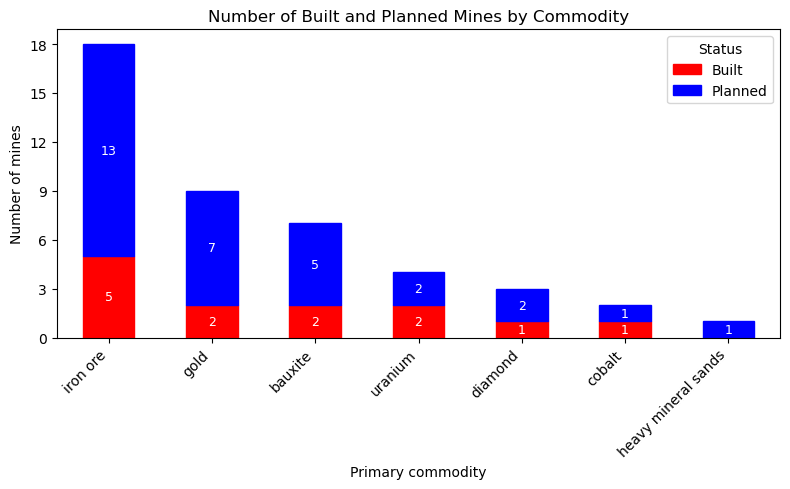

In [90]:
### create a stacked bar chart to show the number of built mines and planned mines by commodity type ###
# group the all_mines_df by 'PRIMARY_COMMODITY' and 'planned_mine' and count the number of mines in each group
mine_counts = (
    all_mines_df.groupby(["PRIMARY_COMMODITY", "planned_mine"])
    .size()
    .unstack(fill_value=0)
)

# sort commodities by total number of mines (planned + built), descending
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(kind="bar", stacked=True, figsize=(8, 5))

# set color for built and planned bars
colors = ["red", "blue"]  # red for built, blue for planned
for i, bar in enumerate(ax.containers):
    plt.setp(bar, color=colors[i])

# optional: clearer legend labels for built_mine values (0=built, 1=planned)
ax.legend(["Built", "Planned"], title="Status")

# label each stack segment with its count
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.ylabel("Number of mines")
plt.xlabel("Primary commodity")
plt.xticks(rotation=45, ha="right")
plt.yticks(range(0, 19, 3))
plt.title("Number of Built and Planned Mines by Commodity")
plt.tight_layout()

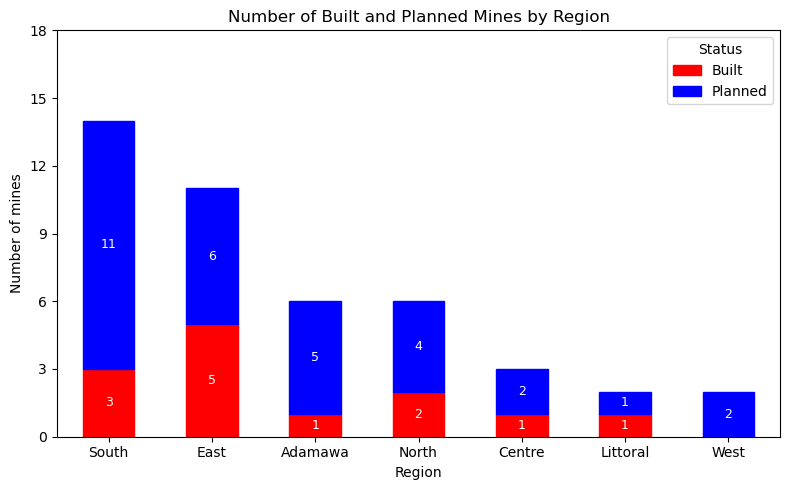

In [98]:
mine_counts = (
    all_mines_df.groupby(["STATE_PROVINCE", "planned_mine"])
    .size()
    .unstack(fill_value=0)
)

# sort commodities by total number of mines (planned + built), descending
mine_counts = mine_counts.loc[mine_counts.sum(axis=1).sort_values(ascending=False).index]

ax = mine_counts.plot(kind="bar", stacked=True, figsize=(8, 5))

# set color for built and planned bars
colors = ["red", "blue"]  # red for built, blue for planned
for i, bar in enumerate(ax.containers):
    plt.setp(bar, color=colors[i])

# optional: clearer legend labels for built_mine values (0=built, 1=planned)
ax.legend(["Built", "Planned"], title="Status")

# label each stack segment with its count
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9, color="white")

plt.ylabel("Number of mines")
plt.xlabel("Region")
plt.xticks(rotation=0, ha="center")
plt.yticks(range(0, 19, 3))
plt.title("Number of Built and Planned Mines by Region")
plt.tight_layout()